Sistema Adaptativo de Saneamento de Dados (SASD)  
Nome: Kauã de Oliveira Ribeiro

Importa as bibliotecas necessárias

In [95]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod

Dados inventados sobre um cenário IoT de várias estações meteorológicas de baixo custo, equipadas com diversos sensores a partir de diferentes microcontroladores.  
Os dados foram separados de acordo com as família de microcontroladores das estações, que apresentam os mesmos padrões de erro

In [96]:
dados_brutos = [
    {"id": "ESP32 S3", "x": "13,00", "y": "45,30", "z": "2,98", "temp": "33,4", "umidade": "64,7", "pressao": "0,97", "pluviometria": "32,0"},
    {"id": "ESP32 C6", "x": "93,30", "y": "19,89", "z": "2,76", "temp": "40,0", "umidade": "N/A", "pressao": "0,97", "pluviometria": "0,0"},
    {"id": "ESP32 C3", "x": "-34,08", "y": "-4,56", "z": "30,45", "temp": "0,0", "umidade": "NaN", "pressao": "0,98", "pluviometria": "15,5"},
    {"id": "ESP32 WROOM", "x": "12,50", "y": " ", "z": "1,11", "temp": "28,9", "umidade": "50,0", "pressao": "1,01", "pluviometria": "5,2"},

    {"id": "raspberry_pi_pico", "x": "100m", "y": "45m", "z": "20m", "temp": "33.4C", "umidade": "64.7%", "pressao": "0.97atm", "pluviometria": "32mm"},
    {"id": "raspberry_pi_4", "x": "120m", "y": "50m", "z": "31.4m", "temp": "45.0C", "umidade": "55%", "pressao": "1.01atm", "pluviometria": "0mm"},
    {"id": "raspberry_pi_zero_2w", "x": "80m", "y": "40m", "z": "11m", "temp": "38.2C", "umidade": "70.1%", "pressao": "0.99atm", "pluviometria": "12mm"},
    {"id": "raspberry_pi_5", "x": "105m", "y": "48m", "z": "2.5m", "temp": "Erro", "umidade": "60%", "pressao": "1.00atm", "pluviometria": "5mm"},

    {"id": " ARDUINO NANO", "x": "", "y": "45.2", "z": "21.2322223", "temp": "33.4", "umidade": " ", "pressao": "0.97", "pluviometria": ""},
    {"id": " ARDUINO MEGA", "x": "11.11", "y": "44.5", "z": "1.9", "temp": "34.1", "umidade": "", "pressao": "0.98", "pluviometria": "30.0"},
    {"id": " ARDUINO UNO ", "x": "", "y": "45.03232", "z": "2.0", "temp": " ", "umidade": "64.7", "pressao": " ", "pluviometria": "32.0"},
    {"id": "ARDUINO DUE", "x": "99.5", "y": "46.0", "z": "2.2", "temp": "", "umidade": "   ", "pressao": "", "pluviometria": " "},

    {"id": "STM32_Nucleo_F4", "x": "1.2e2", "y": "4.5e1", "z": "2.0e0", "temp": "0x21", "umidade": "0x40", "pressao": "0x01", "pluviometria": "0x20"},
    {"id": "STM32_Discovery", "x": "1.0e2", "y": "5.0e1", "z": "3.0e1", "temp": "0x1E", "umidade": "0x3A", "pressao": "0x01", "pluviometria": "0x00"},

    {"id": " bEaGlE bOnE bLaCk", "x": "[98.5]", "y": "False", "z": "None", "temp": "33.4", "umidade": "64.7", "pressao": "0.97", "pluviometria": "32.0"},
    {"id": " BeAgLe bOnE AI ", "x": "[-76.43]", "y": "True", "z": "None", "temp": "40.1", "umidade": "80.0", "pressao": "1.05", "pluviometria": "10.5"},

     {"id": "   ODROID XU4   ", "x": "98.2", "y": "47.0", "z": "92.0", "temp": "null", "umidade": "65.0", "pressao": "0.96", "pluviometria": "31.0"},

    {"id": "STM32_Discovery", "x": "1.0e2", "y": "5.0e1", "z": "3.0e1", "temp": "0x1E", "umidade": "0x3A", "pressao": "0x01", "pluviometria": "0x00"},
    {"id": "ARDUINO DUE", "x": "99.5", "y": "46.0", "z": "2.2", "temp": "", "umidade": "   ", "pressao": "", "pluviometria": " "}
]

Validators personalizados para o cenário fictício retratado

In [97]:
# Classe responsável por determinar quando um valor deve ser aceito e quando deve retornar erro no cenário fictício
class validador_intervalo:
    def __init__(self, min_val, max_val):
        self.min_val = min_val
        self.max_val = max_val
        self.nome = None

    def __set_name__(self, owner, name):
        self.nome = name

    def __get__(self, instance, owner):
        if instance is None:
          return self
        return instance.__dict__.get(self.nome)

    def __set__(self, instance, value):
        if value is not None:
            try:
                val_float = float(value)
                if not (self.min_val <= val_float <= self.max_val):
                    raise ValueError(f"Valor {value} fora do limite ({self.min_val}-{self.max_val}) para '{self.nome}'")
            except ValueError:
                pass
        instance.__dict__[self.nome] = value

# Classe responsável por verificar se os dados são válidos, a partir de validador_intervalo, gravando-os no dataframe final ou não
class registro_sensor:
    umidade = validador_intervalo(0, 100)
    pressao = validador_intervalo(0.3, 1.1)
    temperatura = validador_intervalo(-90, 57)
    pluviometria = validador_intervalo(0, 500)

    def __init__(self, dado_dict):
      self.dado = dado_dict.copy()
      atributos_validados = ["umidade", "pressao", "temp", "pluviometria"]

      for atributo in atributos_validados:
          try:
              self.atributo = self.dado.get(chave)
          except ValueError:
              self.dado[atributo] = None

Classe responsável por definir todos os métodos, funções e lógicas de sanitização dos dados baseado no contexto da aplicação

In [98]:
# Classe base de limpeza dos dados
class saneador(ABC):
    def __init__(self, dados):
        self.dados_brutos = dados
        self.dados_processados = []

    @abstractmethod
    def validar(self):
        # Valida os dados de entrada
        pass

    @abstractmethod
    def limpar(self):
        # Logica principal de limpeza
        pass

# Classe filha de limpeza dos dados
class saneador_sensores(saneador):
    def __init__(self, dados):
        super().__init__(dados)

    @staticmethod
    def limpar_texto(valor):
        # Na primeira etapa, apaga as unidades dos valores caso existam e padroniza os marcadores
        if isinstance(valor, str):
            for char in ["m", "C", "%", "atm", "mm", "[", "]"]:
                valor = valor.replace(char, "")
            valor = valor.replace(",", ".").replace("_", " ").strip()
            return valor
        return valor

    def validar(self):
        # Valida se os intervalos dos valores apresentados pelos sensores estão corretos
        self.dados_brutos = list(filter(lambda x: len(x) > 0, self.dados_brutos))
        return self.dados_brutos

    def limpar(self):
        # Limpa os dados fictícios padronizando a formatação destes
        for dado in self.dados_brutos:
            registro = registro_sensor(dado).dado
            dado_limpo = {}

            for key, value in registro.items():
                if isinstance(value, str):
                    # Converte todos os valores ausentes ou incorretos para None, afim de facilitar o tratamento destes casos posteriormente
                    if value.lower() in ["nan", "", " ", "null", "n/a", "erro", "error", "none", "false", "true"]:
                        value = None
                    # Converte os valores em hexadecimal para float
                    elif value.startswith("0x"):
                        value = str(int(value, 16))
                    # Converte os valores em notação científca para float
                    elif 'e' in value.lower() and key != "id":
                        value = str(float(value))

                if value is not None:
                    # Converte os ids dos dados para strings com todos os caracteres maiúsculos
                    if key == "id":
                        value = str(value).upper().strip()
                    else:
                        # Limpa os dados dos sensores e arredonda os valores float para que apresentem sempre duas casas decimais
                        value = self.limpar_texto(value)
                        try:
                            value = round(float(value), 2)
                        except (ValueError, TypeError):
                            value = None

                dado_limpo[key] = value
            # Salva todos os dados limpos pela classe em uma lista
            self.dados_processados.append(dado_limpo)

Realiza a limpeza dos dados a partir da classe criada anteriormente, elimina as duplicatas e transforma os dados em um dicionário de colunas para facilitar a conversão para um dataframe do pandas posteriormente

In [99]:
# Aplica o processo base de sanitização
pipeline = saneador_sensores(dados_brutos)
pipeline.validar()
pipeline.limpar()

# Converte os dados limpos anteriormente em uma lista de tuplas a fim de eliminar as duplicatas
lista_tuplas = [tuple(d.items()) for d in pipeline.dados_processados]
set_dados_unicos = set(lista_tuplas)
dados_sem_duplicatas = [dict(t) for t in set_dados_unicos]

# Converte o dicionario limpo e sem duplicatas em um dicionário de colunas
chaves = dados_sem_duplicatas[0].keys()
dicionario_de_colunas = {chave: [] for chave in chaves}
for chave in chaves:
    dicionario_de_colunas[chave] = list(map(lambda d: d.get(chave), dados_sem_duplicatas))

print(f"{len(dados_brutos)} registros antes da remoção de duplicatas")
print(f"{len(dados_sem_duplicatas)} registros depois da remoção de duplicatas")
print(dicionario_de_colunas)

19 registros antes da remoção de duplicatas
17 registros depois da remoção de duplicatas
{'id': ['RASPBERRY_PI_ZERO_2W', 'ESP32 C3', 'STM32_NUCLEO_F4', 'ODROID XU4', 'ARDUINO MEGA', 'ESP32 S3', 'ESP32 WROOM', 'RASPBERRY_PI_4', 'ARDUINO UNO', 'STM32_DISCOVERY', 'ARDUINO DUE', 'BEAGLE BONE BLACK', 'ESP32 C6', 'RASPBERRY_PI_PICO', 'ARDUINO NANO', 'BEAGLE BONE AI', 'RASPBERRY_PI_5'], 'x': [80.0, -34.08, 120.0, 98.2, 11.11, 13.0, 12.5, 120.0, None, 100.0, 99.5, 98.5, 93.3, 100.0, None, -76.43, 105.0], 'y': [40.0, -4.56, 45.0, 47.0, 44.5, 45.3, None, 50.0, 45.03, 50.0, 46.0, None, 19.89, 45.0, 45.2, None, 48.0], 'z': [11.0, 30.45, 2.0, 92.0, 1.9, 2.98, 1.11, 31.4, 2.0, 30.0, 2.2, None, 2.76, 20.0, 21.23, None, 2.5], 'temp': [38.2, 0.0, 33.0, None, 34.1, 33.4, 28.9, 45.0, None, 30.0, None, 33.4, 40.0, 33.4, 33.4, 40.1, None], 'umidade': [70.1, None, 64.0, 65.0, None, 64.7, 50.0, 55.0, 64.7, 58.0, None, 64.7, None, 64.7, None, 80.0, 60.0], 'pressao': [None, 0.98, 1.0, 0.96, 0.98, 0.97, 1.01, N

Converte os dados organizados nas últimas etapas em um dataframe pandas, além de atribuir valores fictícios para os dados inexistentes, calculados a partir da média de seus valores adjacentes

In [111]:
df = pd.DataFrame(dicionario_de_colunas)

# Altera o nome das colunas que serão geradas no dataframe
mapa_colunas = {
    "temp": "temperatura [°C]",
    "umidade": "umidade [%]",
    "pressao": "pressao [atm]",
    "pluviometria": "pluviometria [mm]",
    "x": "x",
    "y": "y",
    "z": "z"
}
df.rename(columns=mapa_colunas, inplace=True)

colunas_num = ["x", "y", "z", "temperatura [°C]", "umidade [%]", "pressao [atm]", "pluviometria [mm]"]

df[colunas_num] = df[colunas_num].astype(float)
df[colunas_num] = df[colunas_num].interpolate(method='linear', limit_direction='both')
df.dropna(subset=['id'], inplace=True)

display(df)

,id,x,y,z,temperatura [°C],umidade [%],pressao [atm],pluviometria [mm]
0,RASPBERRY_PI_ZERO_2W,80.000,40.000,11.000,38.20,70.10,0.980000,12.00
1,ESP32 C3,-34.080,-4.560,30.450,0.00,67.05,0.980000,15.50
2,STM32_NUCLEO_F4,120.000,45.000,2.000,33.00,64.00,1.000000,32.00
3,ODROID XU4,98.200,47.000,92.000,33.55,65.00,0.960000,31.00
4,ARDUINO MEGA,11.110,44.500,1.900,34.10,64.85,0.980000,30.00
5,ESP32 S3,13.000,45.300,2.980,33.40,64.70,0.970000,32.00
6,ESP32 WROOM,12.500,47.650,1.110,28.90,50.00,1.010000,5.20
7,RASPBERRY_PI_4,120.000,50.000,31.400,45.00,55.00,1.006667,0.00
8,ARDUINO UNO,110.000,45.030,2.000,37.50,64.70,1.003333,32.00
9,STM32_DISCOVERY,100.000,50.000,30.000,30.00,58.00,1.000000,0.00


Plota os gráficos dos dados organizados para facilitar a análise por parte do usuário

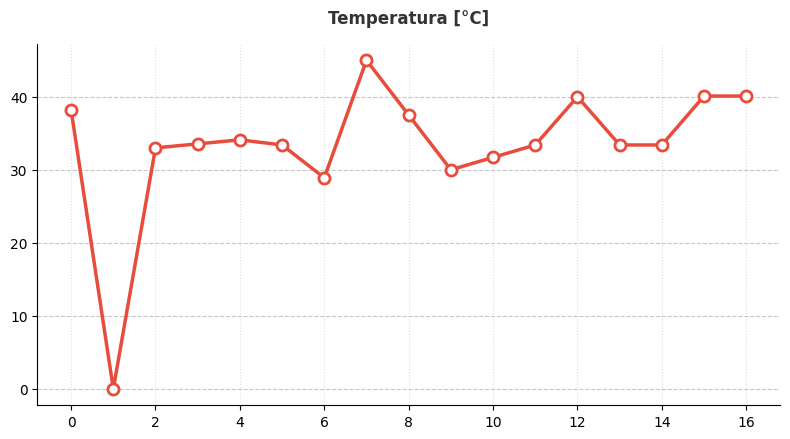

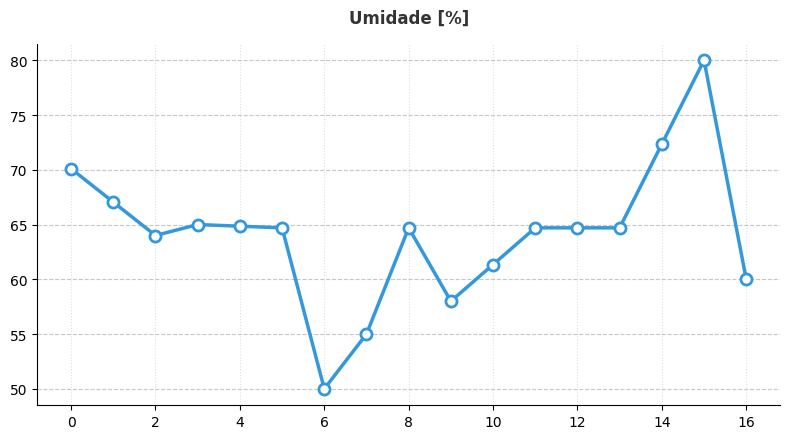

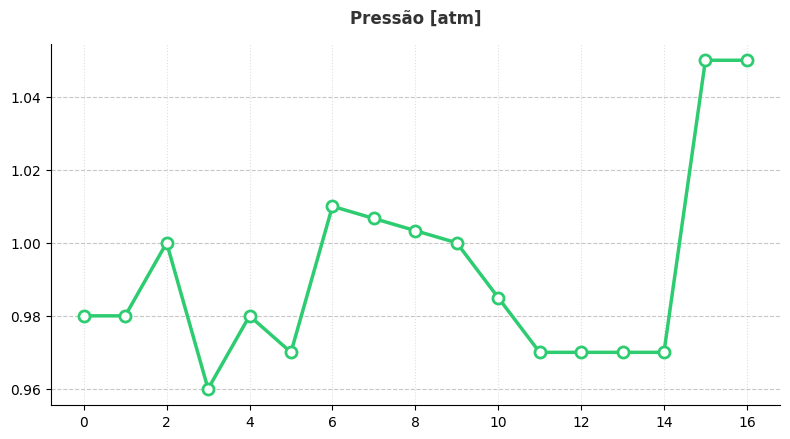

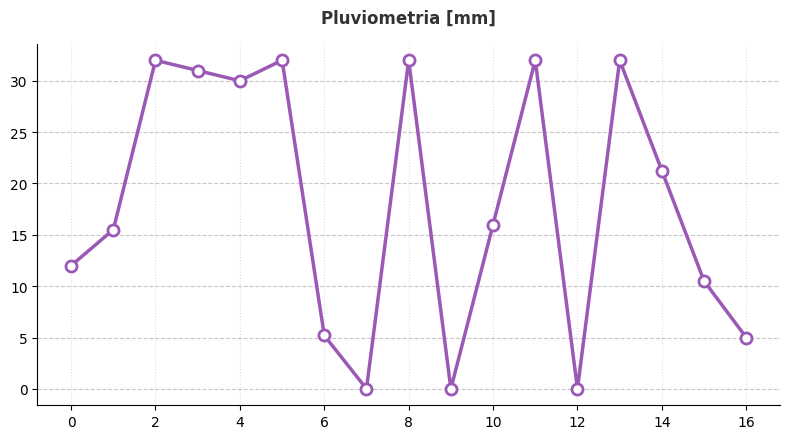

In [101]:
# Mapeamento de cores e títulos para os diferentes gráficos gerados
configuracoes_graficos = {
    'temperatura [°C]': {'cor': '#e74c3c', 'titulo': 'Temperatura [°C]'},
    'umidade [%]': {'cor': '#3498db', 'titulo': 'Umidade [%]'},
    'pressao [atm]': {'cor': '#2ecc71', 'titulo': 'Pressão [atm]'},
    'pluviometria [mm]': {'cor': '#9b59b6', 'titulo': 'Pluviometria [mm]'}
}

# Plota os 4 gráficos desejados
for column, configuracao in configuracoes_graficos.items():
    plt.figure(figsize=(8, 4.5))

    plt.plot(df.index, df[column], marker='o', markersize=8, linestyle='-',
             linewidth=2.5, color=configuracao['cor'], markerfacecolor='white', markeredgewidth=2)

    plt.title(f"{configuracao['titulo']}", fontsize=12, fontweight='bold', color='#333333', pad=15)

    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.grid(True, axis='x', linestyle=':', alpha=0.4)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    print("\n\n")